# LIbreri utilizzate

In [1]:
import numpy as np
import pandas as pd
import math
from scipy.stats import t
import matplotlib.pyplot as plt
from collections import deque
import math, heapq
import os, csv
from collections.abc import Mapping

import matplotlib.pyplot as plt
from typing import Mapping, Iterable, Any, Sequence


In [14]:
#-------------------------------------------------------------------------- 
 #This is an ANSI C library for generating random variates from six discrete 
 #distributions
 #
 #     Generator         Range (x)     Mean         Variance
 #
 #     Bernoulli(p)      x = 0,1       p            p*(1-p)
 #     Binomial(n, p)    x = 0,...,n   n*p          n*p*(1-p)
 #     Equilikely(a, b)  x = a,...,b   (a+b)/2      ((b-a+1)*(b-a+1)-1)/12
 #     Geometric(p)      x = 0,...     p/(1-p)      p/((1-p)*(1-p))
 #     Pascal(n, p)      x = 0,...     n*p/(1-p)    n*p/((1-p)*(1-p))
 #     Poisson(m)        x = 0,...     m            m
 #
 #and seven continuous distributions
 #
 #     Uniform(a, b)     a < x < b     (a + b)/2    (b - a)*(b - a)/12 
 #     Exponential(m)    x > 0         m            m*m
 #     Erlang(n, b)      x > 0         n*b          n*b*b
 #     Normal(m, s)      all x         m            s*s
 #     Lognormal(a, b)   x > 0            see below
 #     Chisquare(n)      x > 0         n            2*n 
 #     Student(n)        all x         0  (n > 1)   n/(n - 2)   (n > 2)
 #
 #For the a Lognormal(a, b) random variable, the mean and variance are
 #
 #                       mean = exp(a + 0.5*b*b)
 #                   variance = (exp(b*b) - 1) #exp(2*a + b*b)
 #
 #Name              : rvgs.c  (Random Variate GeneratorS)
 #Author            : Steve Park & Dave Geyer
 #Language          : ANSI C
 #Latest Revision   : 10-28-98
 #Translated by     : Philip Steele 
 #Language          : Python 3.3
 #Latest Revision   : 3/26/14
 # 
 #--------------------------------------------------------------------------


from math import log,sqrt,exp
# -------------------------------------------------------------------------
# This is an ANSI C library for multi-stream random number generation.  
#  * The use of this library is recommended as a replacement for the ANSI C 
#  * rand() and srand() functions, particularly in simulation applications 
#  * where the statistical 'goodness' of the random number generator is 
#  * important.  The library supplies 256 streams of random numbers; use 
#  * SelectStream(s) to switch between streams indexed s = 0,1,...,255.
#  *
#  * The streams must be initialized.  The recommended way to do this is by
#  * using the function PlantSeeds(x) with the value of x used to initialize 
#  * the default stream and all other streams initialized automatically with
#  * values dependent on the value of x.  The following convention is used 
#  * to initialize the default stream:
#  *    if x > 0 then x is the state
#  *    if x < 0 then the state is obtained from the system clock
#  *    if x = 0 then the state is to be supplied interactively.
#  *
#  * The generator used in this library is a so-called 'Lehmer random number
#  * generator' which returns a pseudo-random number uniformly distributed
#  * 0.0 and 1.0.  The period is (m - 1) where m = 2,147,483,647 and the
#  * smallest and largest possible values are (1 / m) and 1 - (1 / m)
#  * respectively.  For more details see:
#  * 
#  *       "Random Number Generators: Good Ones Are Hard To Find"
#  *                   Steve Park and Keith Miller
#  *              Communications of the ACM, October 1988
#  *
#  * Name            : rngs.c  (Random Number Generation - Multiple Streams)
#  * Authors         : Steve Park & Dave Geyer
#  * Language        : ANSI C
#  * Latest Revision : 09-22-98
#  * Translated by     : Philip Steele 
#  * Language          : Python 3.3
#  * Latest Revision   : 3/26/14
#  *
#  * ------------------------------------------------------------------------- 

from time import time

#global consts
MODULUS = 2147483647 #/* DON'T CHANGE THIS VALUE                  */
MULTIPLIER = 48271      #/* DON'T CHANGE THIS VALUE                  */
CHECK = 399268537  #/* DON'T CHANGE THIS VALUE                  */
STREAMS = 256        #/* # of streams, DON'T CHANGE THIS VALUE    */
A256 = 22925      #/* jump multiplier, DON'T CHANGE THIS VALUE */
DEFAULT = 123456789  #/* initial seed, use 0 < DEFAULT < MODULUS  */

#statics
stream = 0
initialized = 0
seed = [DEFAULT]
for i in range(1,STREAMS):
  seed.append(DEFAULT)


def random(): 
  #/* ---------------------------------------------------------------------
  #* Random is a Lehmer generator that returns a pseudo-random real number
  #* uniformly distributed between 0.0 and 1.0.  The period is (m - 1)
  #* where m = 2,147,483,647 amd the smallest and largest possible values
  #* are (1 / m) and 1 - (1 / m) respectively.
  #* ---------------------------------------------------------------------
  #*/
  global seed

  Q = int(MODULUS / MULTIPLIER)
  R = int(MODULUS % MULTIPLIER)

  t = int(MULTIPLIER * (seed[stream] % Q) - R * int(seed[stream] / Q))
  if (t > 0):
    seed[stream] = int(t)
  else:
    seed[stream] = int(t + MODULUS)

  return float(seed[stream] / MODULUS)

def plantSeeds(x): 
  # /* --------------------------------------------------------------------
  #  * Use this function to set the state of all the random number generator
  #  * streams by "planting" a sequence of states (seeds), one per stream,
  #  * with all states dictated by the state of the default stream.
  #  * The sequence of planted states is separated one from the next by
  #  * 8,367,782 calls to Random().
  #  * ---------------------------------------------------------------------
  #  */
  global initialized
  global stream
  global seed

  Q = int(MODULUS / A256)
  R = int(MODULUS % A256)

  initialized = 1
  s = stream                             #/* remember the current stream */
  selectStream(0)                        #/* change to stream 0          */
  putSeed(x)                             #/* set seed[0]                 */
  stream = s                             #/* reset the current stream    */
  for j in range(1,STREAMS):
    x = int(A256 * (seed[j - 1] % Q) - R * int((seed[j - 1] / Q)))
    if (x > 0):
      seed[j] = x
    else:
      seed[j] = x + MODULUS
  

def putSeed(x):
  # /* -------------------------------------------------------------------
  #  * Use this (optional) procedure to initialize or reset the state of
  #  * the random number generator according to the following conventions:
  #  *    if x > 0 then x is the initial seed (unless too large)
  #  *    if x < 0 then the initial seed is obtained from the system clock
  #  *    if x = 0 then the initial seed is to be supplied interactively
  #  * --------------------------------------------------------------------
  #  */
  global seed 

  ok = False

  if (x > 0):
    x = x % MODULUS  
                            # correct if x is too large  
  if (x < 0): 
    x = time()
    x = x % MODULUS
  
  if (x == 0):
    while (ok == False): 
      line = input("\nEnter a positive integer seed (9 digits or less) >> ")
      x = int(line)
      ok = (0 < x) and (x < MODULUS)
      if (ok == False):
        print("\nInput out of range ... try again\n")
    
    
  seed[stream] = int(x)


def getSeed():
  # /* --------------------------------------------------------------------
  #  * Use this (optional) procedure to get the current state of the random
  #  * number generator.
  #  * --------------------------------------------------------------------
  #  */
  global seed
  return seed[stream]


def selectStream(index):
  #/* ------------------------------------------------------------------
  #* Use this function to set the current random number generator
  #* stream -- that stream from which the next random number will come.
  #* ------------------------------------------------------------------
  #*/
  global stream 

  stream = index % STREAMS
  if (initialized == 0) and (stream != 0):   #/* protect against        */
    plantSeeds(DEFAULT)                     #/* un-initialized streams */
    


  
def testRandom():
  # /* -------------------------------------------------------------------
  #  * Use this (optional) procedure to test for a correct implementation.
  #  * -------------------------------------------------------------------
  #  */

  ok = False

  selectStream(0)                  #/* select the default stream */
  putSeed(1)                       #/* and set the state to 1    */
  for i in range(0,10000):
    u = random()
  x = getSeed()                    #/* get the new state value   */
  ok = (x == CHECK)                #/* and check for correctness */
  
  selectStream(1)                  #/* select stream 1                 */
  plantSeeds(1)                    #/* set the state of all streams    */
  x = getSeed()                    #/* get the state of stream 1       */
  ok = (ok==True) and (x == A256)           #/* x should be the jump multiplier */
  if (ok==True):
    print("\n The implementation of Rngs.py is correct")
  else:
    print("\n ERROR - the implementation of Rngs.py is not correct")

  

def Bernoulli(p):
  #========================================================
  #Returns 1 with probability p or 0 with probability 1 - p. 
  #NOTE: use 0.0 < p < 1.0                                   
  #========================================================
  
  if (random() < 1 - p):
    return(0)
  else:
    return(1)


def Binomial(n,p):
  #================================================================ 
  #Returns a binomial distributed integer between 0 and n inclusive. 
  #NOTE: use n > 0 and 0.0 < p < 1.0
  #================================================================
  
  x = 0

  for i in range(0,n):
    x += Bernoulli(p)
  return (x)

def Equilikely(a,b):
  #===================================================================
  #Returns an equilikely distributed integer between a and b inclusive. 
  #NOTE: use a < b
  #===================================================================
  return (a + int((b - a + 1) * random()))

def Geometric(p):
  #====================================================
  #Returns a geometric distributed non-negative integer.
  #NOTE: use 0.0 < p < 1.0
  #====================================================
  #

  return (int(log(1.0 - random()) / log(p)))


def Pascal(n,p):
  #================================================= 
  #Returns a Pascal distributed non-negative integer. 
  #NOTE: use n > 0 and 0.0 < p < 1.0
  #=================================================
  #
   
  x = 0

  for i in range(0,n):
    x += Geometric(p)
  return (x)

def Poisson(m):
  #================================================== 
  #Returns a Poisson distributed non-negative integer. 
  #NOTE: use m > 0
  #==================================================
  # 
  t = 0.0
  x = 0

  while (t < m): 
    t += Exponential(1.0)
    x += 1
  
  return (x - 1)

def Uniform(a,b):
  #=========================================================== 
  #Returns a uniformly distributed real number between a and b. 
  #NOTE: use a < b
  #===========================================================
  #
  return (a + (b - a) * random())

def Exponential(m):
  #=========================================================
  #Returns an exponentially distributed positive real number. 
  #NOTE: use m > 0.0
  #=========================================================
  #
  return (-m * log(1.0 - random()))

def Hyperexponential(p, l1, l2):
  # ====================================================================
  # Returns a hyperexponential distributed positive real number.
  # NOTE: 0.0 < p < 1.0, l1 > 0.0, l2 > 0.0
  # It returns an exponential with rate l1 with probability p,
  # otherwise with rate l2 with probability (1 - p)
  # ====================================================================
  #
  if (random() < p):
    return Exponential(1.0 / l1)
  else:
    return Exponential(1.0 / l2)

def Erlang(n,b):
  #================================================== 
  #Returns an Erlang distributed positive real number.
  #NOTE: use n > 0 and b > 0.0
  #==================================================
  #
  x = 0.0

  for i in range(0,n): 
    x += Exponential(b)
  return (x)

def Normal(m,s):
  #========================================================================
  #Returns a normal (Gaussian) distributed real number.
  #NOTE: use s > 0.0
  #
  #Uses a very accurate approximation of the normal idf due to Odeh & Evans, 
  #J. Applied Statistics, 1974, vol 23, pp 96-97.
  #========================================================================
  #
  p0 = 0.322232431088     
  q0 = 0.099348462606
  p1 = 1.0                
  q1 = 0.588581570495
  p2 = 0.342242088547     
  q2 = 0.531103462366
  p3 = 0.204231210245e-1  
  q3 = 0.103537752850
  p4 = 0.453642210148e-4  
  q4 = 0.385607006340e-2

  u = random()
  if (u < 0.5):
    t = sqrt(-2.0 * log(u))
  else:
    t = sqrt(-2.0 * log(1.0 - u))

  p   = p0 + t * (p1 + t * (p2 + t * (p3 + t * p4)))
  q   = q0 + t * (q1 + t * (q2 + t * (q3 + t * q4)))

  if (u < 0.5):
    z = (p / q) - t
  else:
    z = t - (p / q)

  return (m + s * z)

def Lognormal(a,b):
  # ==================================================== 
  #Returns a lognormal distributed positive real number. 
  #NOTE: use b > 0.0
  #====================================================
  #
  return (exp(a + b * Normal(0.0, 1.0)))

def Chisquare(n):
  #=====================================================
  #Returns a chi-square distributed positive real number. 
  #NOTE: use n > 0
  #=====================================================
  #
  x = 0.0

  for i in range(0,n):
    z  = Normal(0.0, 1.0)
    x += z * z

  return (x)


def Student(n):
  #=========================================== 
  #Returns a student-t distributed real number.
  #NOTE: use n > 0
  #===========================================
  #
  return (Normal(0.0, 1.0) / sqrt(Chisquare(n) / n))

def testFunctions():
  #tests to ensure that all variates match what was produced by C version of program (with the same order and parameters)

  #bernoulli 
  bern = []
  for i in range(0,10):
    bern.append(Bernoulli(.65))

  if (bern == [0,0,1,0,1,0,1,1,1,1]):
    print("Bernoulli test passed")
  else:
    print("FIX BERNOULLI!")

  #binomial
  bino = Binomial(50,.19)
  if (bino == 7):
    print("Binomial test passed")
  else:
    print("FIX BINOMIAL")
    print(bino)

  #equilikely 
  equi = Equilikely(32,108)
  if (equi ==77):
    print("Equilikely test passed")
  else:
    print("FIX EQUILIKELY")

  #geo test
  geo = []
  for i in range(0,10):
    geo.append(Geometric(.93))

  if (geo == [0,8,4,21,7,3,17,5,14,1]):
    print("Geo test passed")
  else:
    print("Fix geo!")
    print(geo)

  #pascal test
  pas = Pascal(87,.93)
  if (pas == 1407):
    print("Pascal test passed!")
  else:
    print("FIX PASCAL")

  #poisson test
  pois = Poisson(13.3)
  if (pois == 15):
    print("Poisson test passed!")
  else:
    print("FIX POISSON!")

  #uniform test
  uni = Uniform(32,108)
  if (round(uni,6) == 78.976127):
    print("Uniform test passed!")
  else:
    print("FIX UNIFORM. Produced: ", uni)
    print("Expected: 78.976127")

  #exp test
  exp = Exponential(4.7)
  if (round(exp,6) == 4.796404):
    print("Exponential test passed!")
  else:
    print("FIX EXP. Produced: ", exp)
    print("expected: 4.796404")

  #erlang test
  erl = Erlang(41,.08)
  if (round(erl,6) == 2.824873):
    print("Erland test passed!")
  else:
    print("FIX ERLANG Produced: ", erl)
    print("Expected: 2.824873")

  #normal test
  norm = Normal(8.9,4)
  if (round(norm,6) == 8.374243):
    print("Normal test passed!")
  else:
    print("FIX NORMAL Produced: ",norm)
    print("Expected: 8.374243")

  #lognormal test
  lnorm = Lognormal(1.31,1.6)
  if (round(lnorm,6) == 5.533064):
    print("Lognormal test passed!")
  else:
    print("FIX LOGNORMAL Produced: ", lnorm)
    print("Expected: 5.533064")

  #chisq test
  chisq = Chisquare(39)
  if (round(chisq,6) == 33.634524):
    print("Chisquare test passed!")
  else:
    print("FIX CHI-SQUARE - Produced: ", chisq)
    print("Expected: 33.634524")

  #t test
  stu = Student(61)
  if (round(stu,6) == -1.429058):
    print("Student test passed!")
  else:
    print("FIX STUDENT - Produced: ", stu)
    print("Expected: -1.429058")

# Modello Migliorativo 

In [ ]:
import os, csv
from collections.abc import Mapping

# === LISTA UNICA DI TUTTI GLI STREAM ===
ALL_STREAM_NAMES = [
    "STREAM_ARR",
    "STREAM_A1_A", "STREAM_A1_A2",
    "STREAM_A2_A", "STREAM_A2_A2",
    "STREAM_A3_A", "STREAM_A3_A2",
    "STREAM_B_1", "STREAM_B_2",
    "STREAM_P",
    "STREAM_SPILLOVER_A",     
    "STREAM_PROBE",
    "STREAM_LB_A", "STREAM_LB_B",
    "STREAM_LOSS_B", "STREAM_LOSS_A2",
    "STREAM_LOSS_P", "STREAM_LOSS_EXIT",
]


def snapshot_streamsMigliorativo():
    """
    Restituisce un NUOVO dict con il seed corrente per OGNI stream in ALL_STREAM_NAMES.

    Struttura:
        {
            "STREAM_ARR":        seed,
            "STREAM_A1_A":       seed,
            "STREAM_A1_A2":      seed,
            ...
            "STREAM_LOSS_EXIT":  seed,
        }
    """
    out: dict[str, int] = {}
    for name in ALL_STREAM_NAMES:
        idx = globals()[name]       # prende il valore numerico di STREAM_XXX
        selectStream(idx)
        out[name] = getSeed()
    return out


def print_all_streamsMigliorativo():
    """
    Stampa (debug) e ritorna una copia nuova dei seed per ogni stream.
    """
    d = snapshot_streamsMigliorativo()
    for name in ALL_STREAM_NAMES:
        print(f"{name}: {d[name]}")
    return d


def write_streams_csvMigliorativo(
    path: str,
    data: Mapping,               
    *,
    run_field: str = "RUN",
    columns: list[str] | None = None,
    encoding: str = "utf-8"
):
    """
    Scrive il CSV con struttura:

        RUN,STREAM_ARR,STREAM_A1_A,STREAM_A1_A2,...
        0,  ...,        ...,        ...,         ...
        1,  ...,        ...,        ...,         ...
        ...

    dove ogni colonna corrisponde a UNO stream fisico.
    """
    # normalizza in lista ordinata per run_id
    rows = [(run_id, inner) for run_id, inner in sorted(data.items())]

    if columns is None:
        columns = list(ALL_STREAM_NAMES)

    header = [run_field] + columns
    os.makedirs(os.path.dirname(path) or ".", exist_ok=True)

    with open(path, "w", encoding=encoding, newline="") as f:
        w = csv.writer(f)
        w.writerow(header)
        for run_id, inner in rows:
            row = [run_id]
            for col in columns:
                row.append(inner.get(col, ""))
            w.writerow(row)


In [ ]:
# parametri globali per la perdita
LOSS_B = 6.0  # coefficiente p 
LOSS_P = 6.0
LOSS_P_EXIT = 4.0  # esponente della curva tra 2s e 4s
FLAG=False 


def loss_probability_from_sojourn_B(sojourn_sec: float) -> float:
    """
    Probabilità di perdita in funzione del sojourn time (secondi).
    Regole:
      - 0 se t <= 3
      - ((t-2)/3)**LOSS_P per 3 < t < 6 (clamp [0,1])
      - 1 se t >= 6
    """
    try:
        t = float(sojourn_sec)
    except (TypeError, ValueError):
        return 0.0

    if t <= 4.0:
        return 0.0
    if t >= 6.0:
        return 1.0

    val = ((t - 4.0) / 2.0) ** LOSS_B

    if val < 0.0:
        val = 0.0
    elif val > 1.0:
        val = 1.0
    return val

def loss_prob_after_A2(stream_id=18) -> bool:
    selectStream(stream_id)
    u = random()
    return min(max(u, 1e-15), 1.0 - 1e-15) < 0.1
    

def loss_prob_class2_after_P(service_time_p: float) -> float:
    """
    p_loss per CLASSE 2 (dopo P), binaria:
      - 0 se tempo di servizio in P <= T_PAY
      - 1 se tempo di servizio in P >  T_PAY
    """
    try:
        t = float(service_time_p)
    except (TypeError, ValueError):
        return 0.0

    if t <= 10:
        return 0
    if t >= 12.0:
        return 1.0
    val = ((t - 10.0) / 2.0) ** LOSS_P

    if val < 0.0:
        val = 0.0
    elif val > 1.0:
        val = 1.0
    return val

def loss_prob_class3_at_exit(sojourn_sec: float) -> float:
    return 0.0

In [ ]:
# ==============================
#  STREAM IDs
# ==============================

# Arrivi
STREAM_ARR       = 0

# Servizio A1 (prima visita in A)
STREAM_A1_A      = 1   # A fisico
STREAM_A1_A2     = 2   # A2 scalato

# Servizio B
STREAM_B_1       = 3   # B fisico
STREAM_B_2       = 4   # B2 scalato

# Servizio A2 (seconda visita in A)
STREAM_A2_A      = 5
STREAM_A2_A2     = 6

# Servizio P
STREAM_P         = 7

# Servizio A3 (terza visita in A)
STREAM_A3_A      = 8
STREAM_A3_A2     = 9

# Probe / spillover / LB
STREAM_PROBE        = 10   # probe + decisioni P vs spillover
STREAM_LB_A         = 11   # load balancing A/A2
STREAM_LB_B         = 12   # load balancing B/B2
STREAM_SPILLOVER_A  = 13   # servizio dei job rientrati in A/A2

# Perdita: stream separati per ciascun confine
STREAM_LOSS_B    = 14
STREAM_LOSS_A2   = 15
STREAM_LOSS_P    = 16
STREAM_LOSS_EXIT = 17
STREAM_LOSS_RENEGING = 18


# SImulazione con LMB Costante

In [ ]:
def simulate_ps_ABAPA_scaled_AB_with_spillover_and_loss_tags_modified(
    lmb,
    mu_A1, mu_B, mu_A2, mu_P, mu_A3,
    threshold_time,
    *,
    delta_T=10.0,
    warmup_time=0.0,
    k_threshold_A_up=0.0, k_threshold_A_down=-1,
    k_threshold_B_up=0.0, k_threshold_B_down=-1,
    p_send_to_P_init=0.0, p_probe=0.45, window_size=6,
    L_target=8.0, gamma=0.25,
    spillover_demand_const=0.6,
    eps=1e-12,
    FLAG=True  # Parametro per abilitare/disabilitare la simulazione delle perdite
):

    # ================= RNG helper =================
    def U01_from(stream_id):
        selectStream(stream_id)
        u = random()
        return min(max(u, 1e-15), 1.0 - 1e-15)

    # ================= PS Server =================
    class PSServer:
        __slots__ = ("name","c","S","n","heap","N_time_accum","busy_time")
        def __init__(self,name,c=1.0):
            self.name=name; self.c=c
            self.S=0.0; self.n=0
            self.heap=[]
            self.N_time_accum=0.0
            self.busy_time=0.0

    servers = {k:PSServer(k,1.0) for k in ("A","B","P")}

    # ================= Load Balancing =================
    def choose_A_server(now):
        util_A = servers["A"].busy_time / now if now > 0 else 0.0
        util_A2 = servers["A2"].busy_time / now if "A2" in servers and now > 0 else 0.0
        if util_A > k_threshold_A_up:
            if "A2" not in servers:
                servers["A2"] = PSServer("A2")
            p = (1/util_A) / ((1/util_A)+(1/util_A2 if util_A2>0 else 1))
            return "A" if U01_from(STREAM_LB_A) < p else "A2"
        return "A"

    def choose_B_server(now):
        util_B = servers["B"].busy_time / now if now > 0 else 0.0
        util_B2 = servers["B2"].busy_time / now if "B2" in servers and now > 0 else 0.0
        if util_B > k_threshold_B_up:
            if "B2" not in servers:
                servers["B2"] = PSServer("B2")
            p = (1/util_B) / ((1/util_B)+(1/util_B2 if util_B2>0 else 1))
            return "B" if U01_from(STREAM_LB_B) < p else "B2"
        return "B"

    def stage_server_name(pos, now):
        if pos in (1,3,5): return choose_A_server(now)
        if pos == 2: return choose_B_server(now)
        return "P"

    def check_scaledown(now):
        if now <= 0: return
        if "A2" in servers and servers["A2"].n==0 and servers["A"].busy_time/now < k_threshold_A_down:
            del servers["A2"]
        if "B2" in servers and servers["B2"].n==0 and servers["B"].busy_time/now < k_threshold_B_down:
            del servers["B2"]

    # ================= Demand =================
    def a_visit_index_after(pos): return [1,1,2,2,3][pos-1]

    def draw_demand_for(pos, server):
        if pos==1:
            selectStream(STREAM_A1_A if server=="A" else STREAM_A1_A2)
            return Exponential(1/mu_A1)
        if pos==2:
            selectStream(STREAM_B_1 if server=="B" else STREAM_B_2)
            return Exponential(1/mu_B)
        if pos==3:
            selectStream(STREAM_A2_A if server=="A" else STREAM_A2_A2)
            return Exponential(1/mu_A2)
        if pos==4:
            selectStream(STREAM_P)
            return Exponential(1/mu_P)
        selectStream(STREAM_A3_A if server=="A" else STREAM_A3_A2)
        return Exponential(1/mu_A3)

    # ================= Stato =================
    t = 0.0
    selectStream(STREAM_ARR)
    next_arrival = Exponential(1/lmb)

    jobs_info = {}
    jobs_rows = []
    all_stage_records = []

    arrivals_by_server, losses_by_server = {}, {}
    total_arrivals = lost_total = 0

    # ================= Batch temporali =================
    time_batches = []
    current_batch = {
        "batch_id": 0,
        "start": 0.0,
        "area_N": {},        # area per-server
        "area_busy": {},     # busy time per-server
        "completions": 0
    }
    for sname in servers:
        current_batch["area_N"][sname] = 0.0
        current_batch["area_busy"][sname] = 0.0

    next_batch_boundary = delta_T

    # ================= Advance =================
    def advance(delta):
        nonlocal t, current_batch, next_batch_boundary
        while delta > 0:
            dt = min(delta, next_batch_boundary - t)

            # Calcolo dell'area N e area busy per il batch temporale
            for sname, s in servers.items():

                # Inizializzazione lazy se server creato durante il batch
                if sname not in current_batch["area_N"]:
                    current_batch["area_N"][sname] = 0.0
                    current_batch["area_busy"][sname] = 0.0

                current_batch["area_N"][sname] += s.n * dt
                
                if s.n > 0:
                    current_batch["area_busy"][sname] += dt

                # --- LOGICA PS ---
                s.N_time_accum += s.n * dt
                if s.n > 0:
                    s.busy_time += dt
                    s.S += (s.c / s.n) * dt

            # Avanzamento del tempo
            t += dt
            delta -= dt

            # Alla fine di ogni batch, calcoliamo le metriche e le aggiungiamo
            if abs(t - next_batch_boundary) < eps:
                # Registriamo i dati per ogni replica di server (A, A2, B, B2)
                k = current_batch["batch_id"]

                # Calcoliamo medie e utilizzi e li inseriamo nel dizionario batch
                for sname in current_batch["area_N"]:
                    current_batch[f"{sname}_avg_users"] = current_batch["area_N"][sname] / delta_T
                    current_batch[f"{sname}_utilization"] = current_batch["area_busy"][sname] / delta_T

                # Chiudiamo il batch corrente
                current_batch["end"] = t
                if t > warmup_time:
                    time_batches.append(current_batch)

                # Resettiamo i valori per il prossimo batch
                current_batch = {
                    "batch_id": current_batch["batch_id"] + 1,
                    "start": t,
                    "area_N": {},
                    "area_busy": {},
                    "completions": 0
                }
                for sname in servers:
                    current_batch["area_N"][sname] = 0.0
                    current_batch["area_busy"][sname] = 0.0

                next_batch_boundary += delta_T

    # ================= Admission =================
    def admit_segment(jid, pos, server):
        d = draw_demand_for(pos, server)
        s = servers[server]
        seg = {
            "job_id": jid, "pos": pos, "server": server,
            "IN": t, "Demand": d,
            "N_at_Admit": s.n + 1
        }
        F = s.S + d
        heapq.heappush(s.heap, (F, jid, seg))
        s.n += 1

    # ================= Event Loop =================
    job_id = 0
    INF = float("inf")

    def arrivals_open():
        return next_arrival is not None and next_arrival <= threshold_time

    # Variabili per tenere traccia delle perdite per ogni server
    loss_on_b = 0
    loss_on_a2 = 0
    loss_on_p = 0
    loss_on_exit = 0

    while arrivals_open() or any(s.n > 0 for s in servers.values()):

        next_comp = INF
        comp_srv = None
        for s in servers.values():
            if s.n == 0: continue
            F, _, _ = s.heap[0]
            dt = max(0.0, (F - s.S) * (s.n / s.c))
            if t + dt < next_comp:
                next_comp = t + dt
                comp_srv = s

        ta = next_arrival if arrivals_open() else INF
        t_next = min(ta, next_comp)
        if t_next == INF: break

        advance(t_next - t)
        check_scaledown(t)

        if abs(t_next - ta) < eps:
            job_id += 1
            jid = job_id
            total_arrivals += 1
            jobs_info[jid] = {"arrival0": t, "stage_recs": [], "demand_total": 0.0}
            admit_segment(jid, 1, stage_server_name(1, t))
            selectStream(STREAM_ARR)
            ia = Exponential(1 / lmb)
            next_arrival = t + ia if t + ia <= threshold_time else None
        else:
            # ================= COMPLETION =================
            F, jid, seg = heapq.heappop(comp_srv.heap)
            comp_srv.n -= 1

            IN = seg["IN"]
            OUT = t

            rec = {
                "jid": jid,
                "pos": seg["pos"],
                "server": seg["server"],
                "IN": IN,
                "OUT": OUT,
                "Service": OUT - IN,
                "N_at_Admit": seg["N_at_Admit"]
            }

            jobs_info[jid]["stage_recs"].append(rec)
            all_stage_records.append(rec)
            jobs_info[jid]["demand_total"] += seg["Demand"]

            # ================= LOSS CHECK =================
            lost_here = False
            lost_stage = None

            if FLAG:
                if seg["pos"] == 2:
                    p_loss = float(loss_probability_from_sojourn_B(rec["Service"]))
                    if U01_from(STREAM_LOSS_B) < p_loss:
                        loss_on_b += 1
                        lost_here = True
                        lost_stage = 2

                #elif seg["pos"] == 3 and not jobs_info[jid].get("spillover_used", False):
                    #p_loss = 0.1
                    #if U01_from(STREAM_LOSS_A2) < p_loss:
                        #loss_on_a2 += 1
                        #lost_here = True
                        #lost_stage = 3

                elif seg["pos"] == 4:
                    p_loss = float(loss_prob_class2_after_P(rec["Service"]))
                    if U01_from(STREAM_LOSS_P) < p_loss:
                        loss_on_p += 1
                        lost_here = True
                        lost_stage = 4

                elif seg["pos"] == 5:
                    p_loss = float(loss_prob_class3_at_exit(rec["Service"]))
                    if U01_from(STREAM_LOSS_EXIT) < p_loss:
                        loss_on_exit += 1
                        lost_here = True
                        lost_stage = 5

            # ================= JOB LOST =================
            if lost_here:
                jobs_rows.append({
                    "OrigID": jid,
                    "Arrival0": jobs_info[jid]["arrival0"],
                    "Completion": t,                     # istante di perdita
                    "TempoRispostaTotal": t - jobs_info[jid]["arrival0"],
                    "Lost": True,
                    "LostStage": lost_stage
                })
                continue   # il job MUORE qui (niente routing)

            # ================= ROUTING NORMALE =================
            if seg["pos"] < 5:
                admit_segment(
                    jid,
                    seg["pos"] + 1,
                    stage_server_name(seg["pos"] + 1, t)
                )
            else:
                current_batch["completions"] += 1
                jobs_rows.append({
                    "OrigID": jid,
                    "Arrival0": jobs_info[jid]["arrival0"],
                    "Completion": t,
                    "TempoRispostaTotal": t - jobs_info[jid]["arrival0"],
                    "Lost": False,
                    "LostStage": None
                })

    # Stampa delle perdite totali, se FLAG è attivo
    if FLAG:
        print(f"Total losses on B: {loss_on_b}")
        print(f"Total losses on A2: {loss_on_a2}")
        print(f"Total losses on P: {loss_on_p}")
        print(f"Total losses on Exit: {loss_on_exit}")

    # Convertiamo time_batches in DataFrame
    time_batch_df = pd.DataFrame(time_batches)

    df = pd.DataFrame(jobs_rows)
    df_stages = pd.DataFrame(all_stage_records).rename(columns={"IN": "Arrival", "OUT": "Completion"})

    return df, time_batch_df, df_stages


In [ ]:
import numpy as np
import pandas as pd

# ================================
# Autocorrelazione lag-1
# ================================
def lag1_autocorr(x):
    x = np.asarray(x)
    if len(x) < 3:
        return np.nan
    x_mean = np.mean(x)
    num = np.sum((x[:-1] - x_mean) * (x[1:] - x_mean))
    den = np.sum((x - x_mean) ** 2)
    return num / den if den > 0 else np.nan


# ================================
# CHATFIELD CHECK 
# ================================
def chatfield_ok(series):
    m = len(series)
    if m < 3:
        return False, np.nan, np.nan
    rho1 = lag1_autocorr(series)
    threshold = 2.0 / np.sqrt(m)
    return abs(rho1) < threshold, rho1, threshold


# ===========================================
# CHECK ESTESO: doppia soglia, Chatfield e 02
# ===========================================
def autocorr_check(series, fixed_thr=0.2):
    series = np.asarray(series)

    if len(series) < 3:
        return {
            "rho1": np.nan,
            "chatfield_thr": np.nan,
            "fixed_thr": fixed_thr,
            "ok_chatfield": False,
            "ok_fixed": False
        }

    rho1 = lag1_autocorr(series)
    m = len(series)
    chat_thr = 2.0 / np.sqrt(m)
    
    #print(f"DEBUG: rho1={rho1:.10f}, chatfield_thr={chat_thr:.10f}, abs(rho1) < chat_thr? {abs(rho1) < chat_thr}")

    return {
        "rho1": rho1,
        "chatfield_thr": chat_thr,
        "fixed_thr": fixed_thr,
        "ok_chatfield": abs(rho1) < chat_thr,
        "ok_fixed": abs(rho1) < fixed_thr
    }


# ================================
# JOB-BASED — RT di sistema
# ================================
def job_based_station_RT_series(df, df_stages, batch_size):
    """
    Restituisce serie di batch means:
    - RT_mean: tempo di risposta complessivo
    - RT_<server>: tempo medio per job presso ciascuna stazione
    """

    # --------------------------------
    # Definizione dei job batch
    # --------------------------------
    df_jobs = df.sort_values("Completion").reset_index(drop=True)
    df_jobs["job_batch"] = df_jobs.index // batch_size

    job_batch_map = df_jobs[["OrigID", "job_batch"]]

    # --------------------------------
    # RT di sistema
    # --------------------------------
    RT_system = (
        df_jobs
        .groupby("job_batch")["TempoRispostaTotal"]
        .mean()
        .values
    )

    series = {
        "RT_system": RT_system
    }

    # --------------------------------
    # Merge con df_stages
    # --------------------------------
    df_st = df_stages.merge(
        job_batch_map,
        left_on="jid",
        right_on="OrigID",
        how="inner"
    )

    # --------------------------------
    # RT medio per stazione (server)
    # --------------------------------
    for srv in sorted(df_st["server"].unique()):
        srv_series = (
            df_st[df_st["server"] == srv]
            .groupby("job_batch")["Service"]
            .mean()
            .values
        )

        series[f"RT_{srv}"] = srv_series

    return series


# ================================
# TIME-BASED — metriche per server
# ================================
def time_based_series(time_batch_df):
    series = {}

    # AvgN e Utilization per server
    for col in time_batch_df.columns:
        if col.endswith("_avg_users") or col.endswith("_utilization"):
            series[col] = time_batch_df[col].values

    # Throughput temporale globale
    T = time_batch_df["end"] - time_batch_df["start"]
    series["Throughput"] = time_batch_df["completions"].values / T.values

    return series


# ================================
# VALIDAZIONE AUTOCORRELAZIONE
# JOB-BASED + TIME-BASED
# ================================
def check_batch_independence(
    df,
    time_batch_df,
    df_stages,
    batch_size=8192,
    fixed_thr=0.2
):
    """
    Verifica indipendenza dei batch tramite autocorrelazione lag-1:
    - Job-based: RT sistema + RT per stazione
    - Time-based: metriche temporali 
    """

    results = {
        "batch_size": batch_size,
        "job_based": {},
        "time_based": {}
    }

    # ============================================================
    # JOB-BASED
    # ============================================================

    # --- RT di sistema + RT per stazione ---
    job_series = job_based_station_RT_series(
        df=df,
        df_stages=df_stages,
        batch_size=batch_size
    )


    for name, series in job_series.items():
        results["job_based"][name] = autocorr_check(
            series,
            fixed_thr=fixed_thr
        )

    # ============================================================
    # TIME-BASED
    # ============================================================

    time_series = time_based_series(time_batch_df)

    for name, series in time_series.items():
        results["time_based"][name] = autocorr_check(
            series,
            fixed_thr=fixed_thr
        )

    return results

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t

# ============================================================
# IC Student-t su batch means
# ============================================================
def mean_ci(x, alpha=0.05):
    x = np.asarray(x)
    K = len(x)
    if K < 2:
        return None, None, (None, None)
    m = x.mean()
    s = x.std(ddof=1)
    tval = t.ppf(1 - alpha/2, K - 1)
    hw = tval * s / np.sqrt(K)
    return m, hw, (m - hw, m + hw)

# ============================================================
# ORCHESTRATORE
# ============================================================
def plot_simulation_results(df, time_batch_df, df_stages,
                            job_batch_size=4096, alpha=0.05):

    # ============================================================
    # JOB-BASED BATCHING GLOBALE
    # ============================================================
    df = df.sort_values("Completion").reset_index(drop=True)
    df["job_batch"] = df.index // job_batch_size

    job_batch_map = df[["OrigID", "job_batch"]].copy()



    # ============================================================
    # 1) SYSTEM RESPONSE TIME — job-based batch means
    #    IC mostrati su OGNI batch
    # ============================================================

    # Ordinamento job 
    df_jobs = df.sort_values("Completion").reset_index(drop=True)

    K_sys = len(df_jobs) // job_batch_size
    if K_sys < 2:
        print("Batch size troppo grande o pochi dati: plot saltato.")
    else:
        # Batch means
        sys_batches = np.array([
            df_jobs.iloc[i*job_batch_size:(i+1)*job_batch_size]["TempoRispostaTotal"].mean()
            for i in range(K_sys)
        ])

        # Statistiche sui batch means
        m = sys_batches.mean()
        s = sys_batches.std(ddof=1)
        tval = t.ppf(1 - alpha/2, K_sys - 1)

        # Half-width globale 
        hw = tval * s / np.sqrt(K_sys)

    # ============================================================
    # PARAMETRO DI VISUALIZZAZIONE
    # ============================================================
    plot_stride = 5   # <<< REGOLABILE

    x = np.arange(1, K_sys + 1)

    # Indici da plottare
    idx = np.arange(0, K_sys, plot_stride)

    plt.figure(figsize=(12, 5))

    # 1) Curva dei batch means (diradata)
    plt.plot(
    x[idx],
    sys_batches[idx],
    marker="o",
    linewidth=2,
    label="Batch mean"
    )

    # 2) IC verticali (stesso hw globale)
    plt.errorbar(
    x[idx],
    sys_batches[idx],
    yerr=hw,
    fmt="none",
    capsize=4,
    alpha=0.8,
    label="± IC"
    )

    # 3) Media globale
    plt.axhline(
    m,
    linestyle="--",
    linewidth=2,
    label=f"Mean = {m:.4f}"
    )

    # 4) IC numerico in legenda
    plt.plot(
    [],
    [],
    " ",
    label=f"IC {100*(1-alpha):.1f}% = [{m-hw:.4f}, {m+hw:.4f}]"
    )

    plt.xlabel("Job batch")
    plt.ylabel("Mean response time")
    plt.title("System response time")
    plt.grid(True)
    plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
    plt.tight_layout()
    plt.show()


# ============================================================
# 2) SERVER / STATION — curve distinte per VISITA (pos)
# ============================================================

    df_stages = df_stages.merge(
    job_batch_map,
    left_on="jid",
    right_on="OrigID",
    how="left"
    )


    for srv in df_stages["server"].unique():

        df_srv = df_stages[df_stages["server"] == srv]

        plt.figure(figsize=(12, 5))

        for pos in sorted(df_srv["pos"].unique()):

            data = (
            df_srv[df_srv["pos"] == pos]
            .groupby("job_batch")["Service"]
            .mean()
            .values
            )

            if len(data) < 2:
                continue

        # IC Student-t PER VISITA
            m, hw, ci = mean_ci(data, alpha)

            plot_stride = 5   

            x_full = np.arange(1, len(data) + 1)
            idx = np.arange(0, len(data), plot_stride)

            # 1) Curva batch means (diradata)
            line, = plt.plot(
            x_full[idx],
            data[idx],
            marker="o",
            linewidth=2,
            label=f"{srv}{pos}"
            )

            color = line.get_color()

        # 2) IC verticali
            plt.errorbar(
            x_full[idx],
            data[idx],
            yerr=hw,
            fmt="none",
            ecolor=color,
            capsize=4,
            alpha=0.8
            )

        # 3) Media per visita
            plt.axhline(
            m,
            linestyle="--",
            linewidth=2,
            color=color
            )

        # 4) Legenda descrittiva
            plt.plot(
            [],
            [],
            color=color,
            linestyle="--",
            label=(
        f"{srv}{pos} mean = {m:.4f}  |  "
        f"IC {100*(1-alpha):.0f}% = "
        f"[{ci[0]:.4f}, {ci[1]:.4f}]"
                )
            )

        plt.xlabel("Job batch") 
        plt.ylabel("Mean response time (PS)") 
        plt.title(f"Response time per visit — Server {srv}") 
        plt.grid(True) 
        # Legenda esterna 
        plt.legend(loc="center left", bbox_to_anchor=(1, 0.5)) 
        plt.tight_layout() 
        plt.show()


def plot_time_based_batches(time_batch_df, delta_T, alpha=0.05, plot_stride=5):
    # Individua tutti i server e differenzia avg_users e utilization
    cols = time_batch_df.columns
    # Trova nomi server da colonne avg_users e utilization
    avg_users_cols = [c for c in cols if c.endswith("_avg_users")]
    utilization_cols = [c for c in cols if c.endswith("_utilization")]

    # Estrazione server base (es. "A", "A2", "B", "B2", "P") senza suffissi
    servers_avg = [c.replace("_avg_users", "") for c in avg_users_cols]
    servers_util = [c.replace("_utilization", "") for c in utilization_cols]

    # Funzione per calcolare mean, half-width (IC) per un vettore
    def compute_stats(arr):
        K = len(arr)
        if K < 2:
            return None, None, (None, None)
        m = np.mean(arr)
        s = np.std(arr, ddof=1)
        tval = t.ppf(1 - alpha/2, K-1)
        hw = tval * s / np.sqrt(K)
        return m, hw, (m - hw, m + hw)

    # Preparazione figure per avg_users e utilization
    fig_avg, ax_avg = plt.subplots(figsize=(12,6))
    fig_util, ax_util = plt.subplots(figsize=(12,6))

    # Definizione gruppi di server replicati
    groups = {
        "A": ["A", "A2"],
        "B": ["B", "B2"],
        "P": ["P"]
    }

    colors_base = {
        "A": "tab:blue",
        "A2": "tab:cyan",
        "B": "tab:orange",
        "B2": "tab:red",
        "P": "tab:green"
    }

    # Funzione helper per plot singolo server in un dato asse
    def plot_server_curve(ax, data, label, color):
        K = len(data)
        if K < 2:
            return
        x = np.arange(1, K+1)
        idx = np.arange(0, K, plot_stride)
        m, hw, ci = compute_stats(data)
        if m is None:
            return
        line, = ax.plot(x[idx], data[idx], marker='o', label=label, color=color, linewidth=2)
        ax.errorbar(x[idx], data[idx], yerr=hw, fmt='none', ecolor=color, capsize=4, alpha=0.8)
        ax.axhline(m, linestyle='--', color=color, linewidth=2)
        ax.plot([], [], color=color, linestyle='--',
                label=f"{label} mean={m:.3f} | IC [{ci[0]:.3f}, {ci[1]:.3f}]")

    # Plot avg_users
    for group_name, members in groups.items():
        for srv in members:
            col_name = f"{srv}_avg_users"
            if col_name in avg_users_cols:
                data = time_batch_df[col_name].values
                plot_server_curve(ax_avg, data, srv, colors_base.get(srv, "black"))

    ax_avg.set_xlabel("Time batch")
    ax_avg.set_ylabel(f"Average number of users per server")
    ax_avg.set_title("Average number of users per server")
    ax_avg.grid(True)
    ax_avg.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    fig_avg.tight_layout()

    # Plot utilization
    for group_name, members in groups.items():
        for srv in members:
            col_name = f"{srv}_utilization"
            if col_name in utilization_cols:
                data = time_batch_df[col_name].values
                plot_server_curve(ax_util, data, srv, colors_base.get(srv, "black"))

    ax_util.set_xlabel("Time batch")
    ax_util.set_ylabel("Utilization")
    ax_util.set_title("Server utilization")
    ax_util.grid(True)
    ax_util.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    fig_util.tight_layout()

    plt.show()


In [22]:
# ================================
# RUN VERIFICATION
# ================================
plantSeeds(123456789)

df, time_batch_df, df_stages = simulate_ps_ABAPA_scaled_AB_with_spillover_and_loss_tags_modified(
    lmb=1.2,
    mu_A1=5.0,
    mu_B=1.25,
    mu_A2=2.5,
    mu_P=2.5,
    mu_A3=10,
    threshold_time=3_000_000,
    delta_T=3413,
    warmup_time=0.0,
    k_threshold_A_up=0, k_threshold_A_down=-1,
    k_threshold_B_up=0, k_threshold_B_down=-1,
    p_send_to_P_init=0.0, p_probe=0.0, window_size=6,
    L_target=8.0, gamma=0.25,
    spillover_demand_const=0.6,
    eps=1e-12,
    FLAG=True 
)

# Stampa numero di batch job e temporali
print(f"Numero di job: {df['batch'].nunique() if 'batch' in df.columns else len(df)}")
print(f"Numero di campionamenti temporali: {time_batch_df['batch_time'].nunique() if 'batch_time' in time_batch_df.columns else len(time_batch_df)}")


Total losses on B: 149725
Total losses on A2: 0
Total losses on P: 330
Total losses on Exit: 0
Numero di job: 3599303
Numero di campionamenti temporali: 878


In [23]:
res = check_batch_independence(
    df,
    time_batch_df,
    df_stages,
    batch_size=4096,
    fixed_thr=0.2
)

print("=== JOB-BASED BATCHES ===")
for metric, out in res["job_based"].items():
    print(
        f"{metric:12s} | "
        f"rho1={out['rho1']:.4f} | "
        f"Chatfield OK={out['ok_chatfield']} | "
        f"Fixed OK={out['ok_fixed']}"
    )

print("\n=== TIME-BASED BATCHES ===")
for metric, out in res["time_based"].items():
    print(
        f"{metric:12s} | "
        f"rho1={out['rho1']:.4f} | "
        f"Chatfield OK={out['ok_chatfield']} | "
        f"Fixed OK={out['ok_fixed']}"
    )

=== JOB-BASED BATCHES ===
RT_system    | rho1=-0.0370 | Chatfield OK=True | Fixed OK=True
RT_A         | rho1=0.0247 | Chatfield OK=True | Fixed OK=True
RT_A2        | rho1=-0.0302 | Chatfield OK=True | Fixed OK=True
RT_B         | rho1=-0.0457 | Chatfield OK=True | Fixed OK=True
RT_B2        | rho1=-0.0678 | Chatfield OK=False | Fixed OK=True
RT_P         | rho1=-0.0106 | Chatfield OK=True | Fixed OK=True

=== TIME-BASED BATCHES ===
A_avg_users  | rho1=0.0389 | Chatfield OK=True | Fixed OK=True
A_utilization | rho1=-0.0091 | Chatfield OK=True | Fixed OK=True
B_avg_users  | rho1=-0.0281 | Chatfield OK=True | Fixed OK=True
B_utilization | rho1=-0.0273 | Chatfield OK=True | Fixed OK=True
P_avg_users  | rho1=-0.0408 | Chatfield OK=True | Fixed OK=True
P_utilization | rho1=-0.0332 | Chatfield OK=True | Fixed OK=True
A2_avg_users | rho1=-0.0627 | Chatfield OK=True | Fixed OK=True
A2_utilization | rho1=-0.0526 | Chatfield OK=True | Fixed OK=True
B2_avg_users | rho1=-0.0764 | Chatfield OK=Fal

Numero di job batch (batch_size=4096): 878


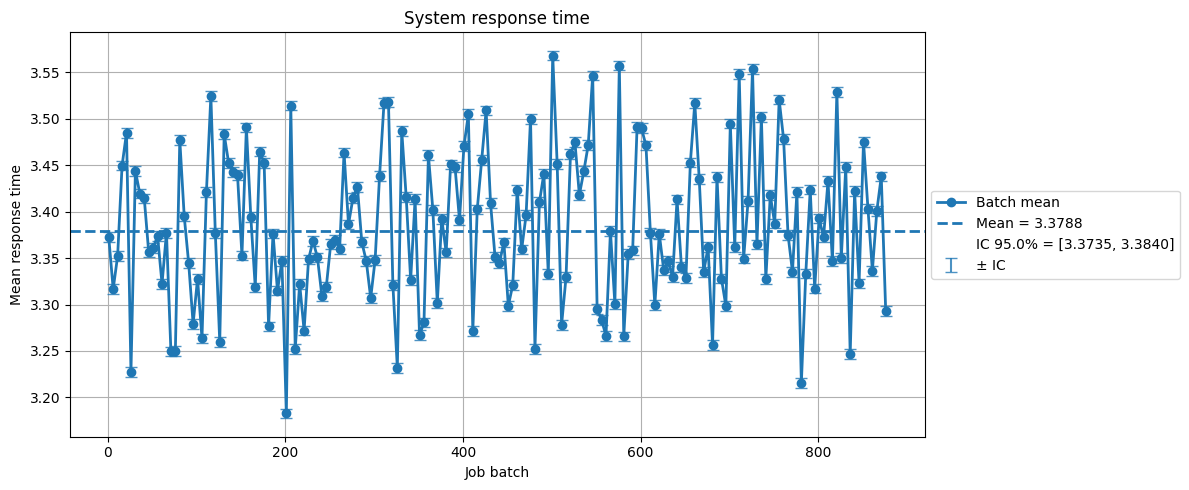

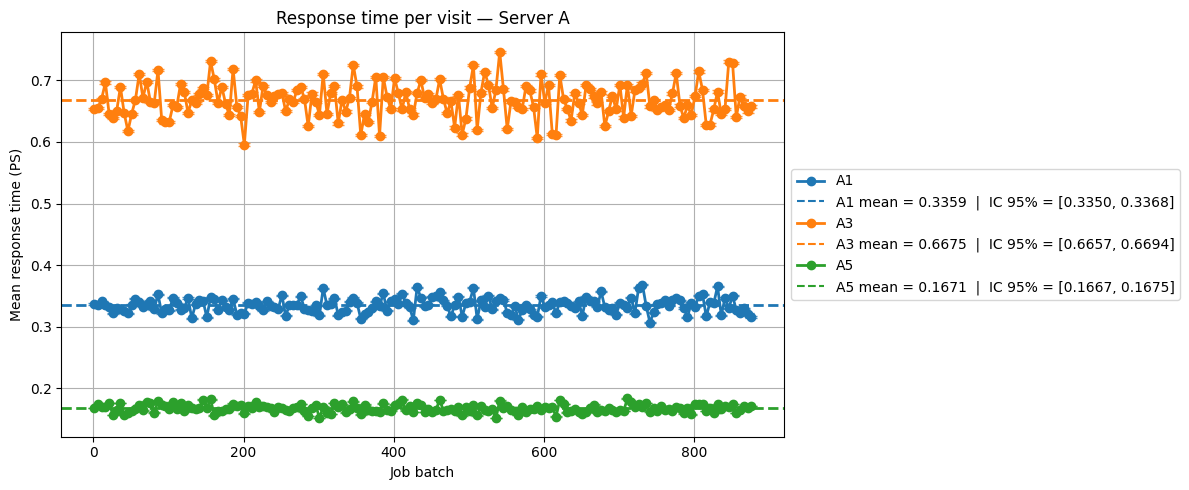

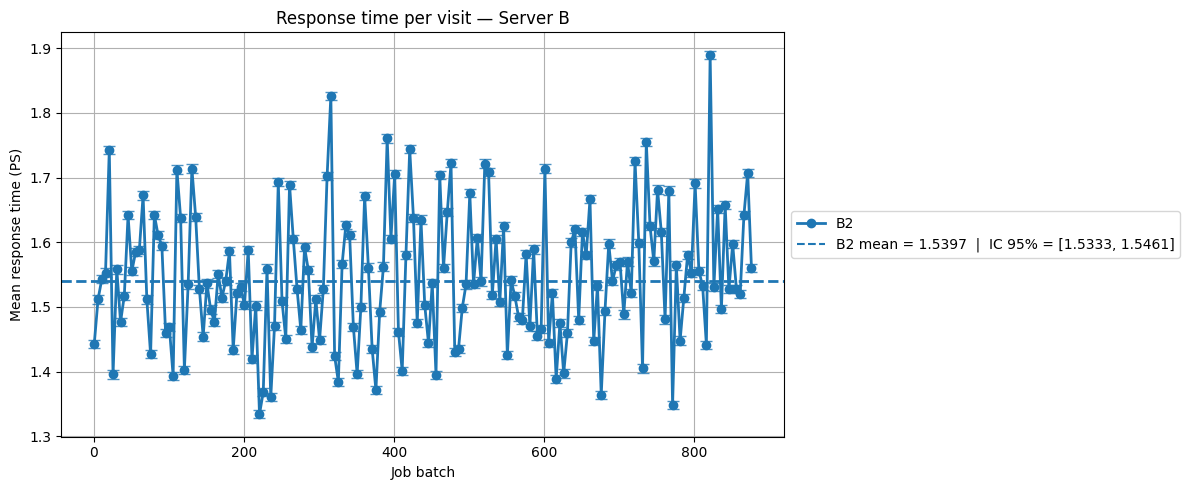

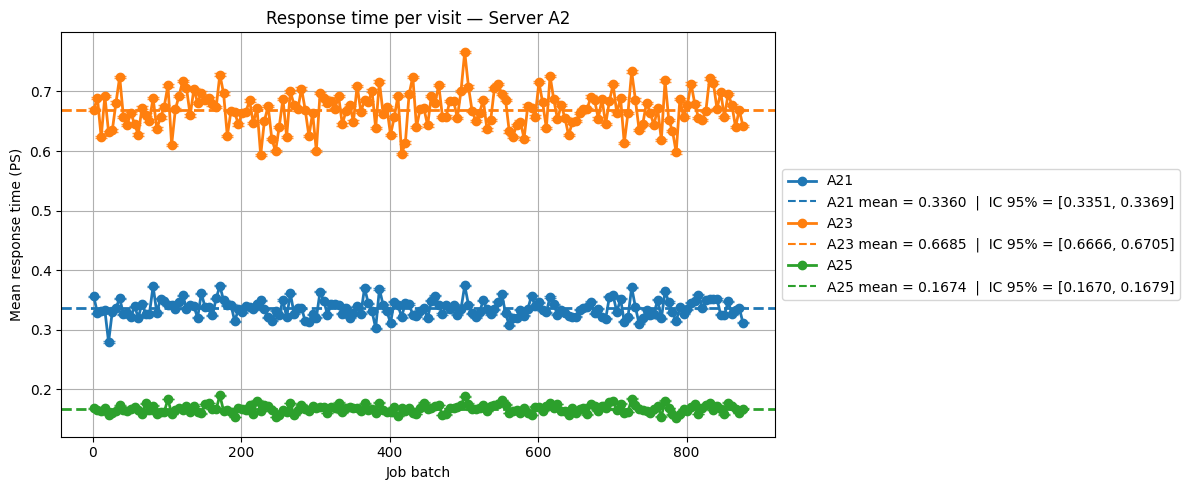

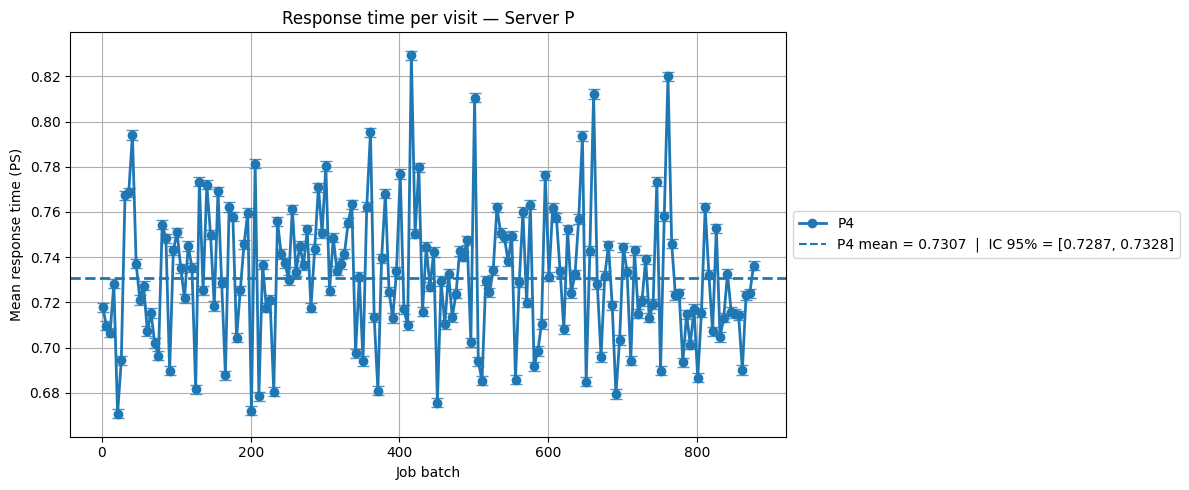

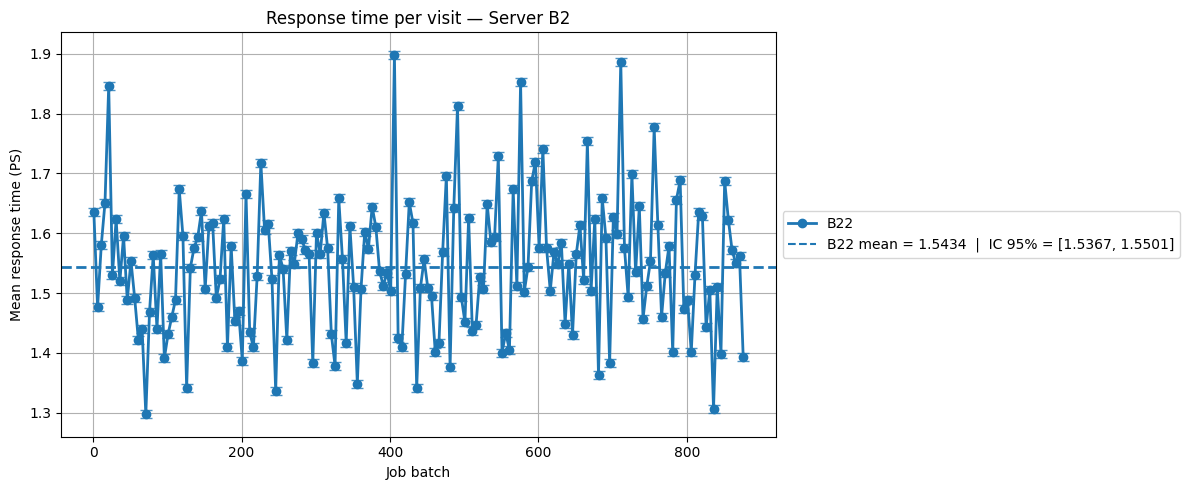

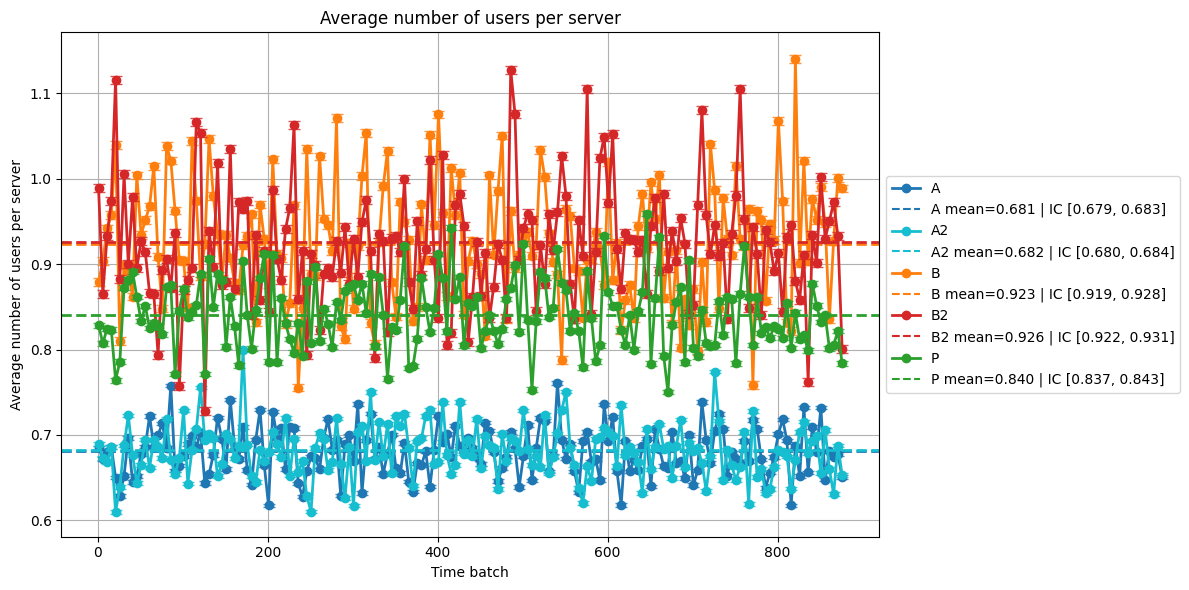

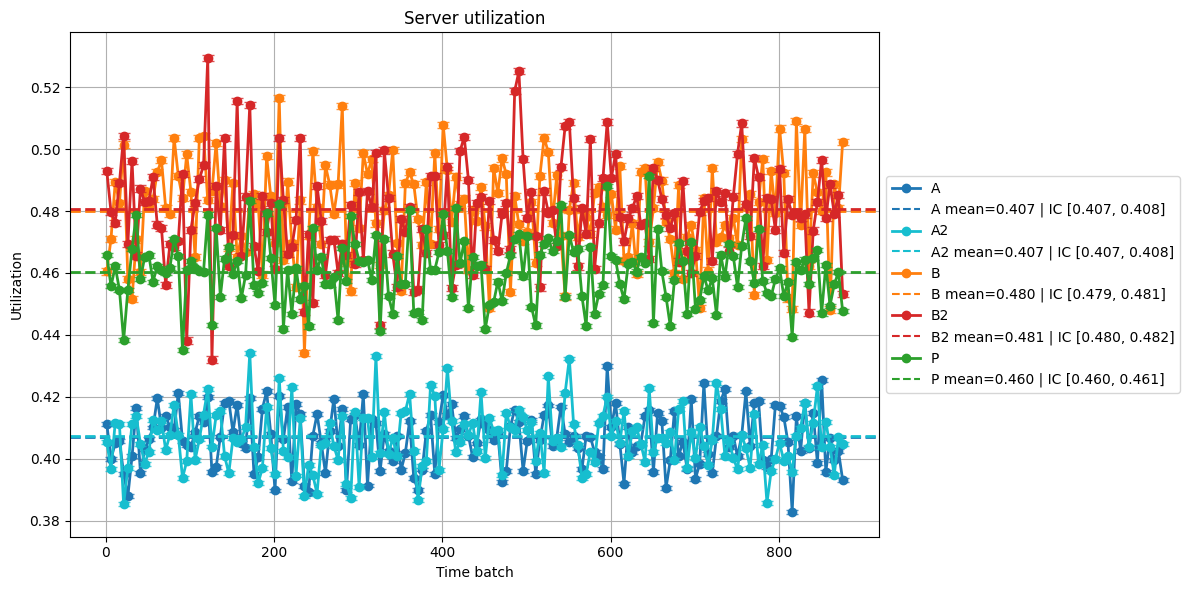

In [24]:
num_job_batches = len(df) // 4096

print(f"Numero di job batch (batch_size=4096): {num_job_batches}")

plot_simulation_results(df, time_batch_df, df_stages)
plot_time_based_batches(time_batch_df, delta_T=10000.0, alpha=0.05)